In [213]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredText
from matplotlib.ticker import StrMethodFormatter, NullFormatter, ScalarFormatter, LogLocator
import pandas as pd
import seaborn as sb
import seaborn.objects as so

In [214]:
nnzs = pd.read_csv("../results/NEON-CPU.csv")
df = pd.read_csv("variations_gpu.csv", skip_blank_lines=True)
cpu = pd.read_csv("variations_cpu_polyester_pinnedthreads.csv", skip_blank_lines=True)
serial = pd.read_csv("variations_serial.csv", skip_blank_lines=True)
icofoam = pd.read_csv("../results/icofoam-h200.csv")

def insertnnz(df):
    df["cells"] = df["case_long"].apply(lambda x: int(x.split("-")[1]))
    c = sorted(df["cells"].unique())
    n = sorted(nnzs["nnz"].unique())
    d = {cc: nn for cc,nn in zip(c,n)}
    df["nnz"] = df["cells"].apply(lambda x: d[x] )
    return df
df = insertnnz(df)
cpu = insertnnz(cpu)
serial = insertnnz(serial)

In [215]:
S = {
    "faceBased": "Face-based",
    "globalFaceBased": "Global Face-based",
    "cellBased" : "Cell-based",
    "batchedFace" : "Batched Face-based"
}
M= {
    "PrecalculatedWeightsUpwind": "Upwind (Prec.)",
    "PrecalculatedWeightsCDF": "Linear (Prec.)",
    "DynamicUpwind": "Upwind (Dyn.)",
    "DynamicCDF": "Linear (Dyn.)",
    "HardCodedCDF": "Linear (Stat.)",
    "HardCodedUpwind": "Upwind (Stat.)",
    "FusedDivLap": "Fused",
    "Fused": "Fused"
}
T= {
    "PrecalculatedWeightsUpwind": "Precalculated Weights",
    "PrecalculatedWeightsCDF": "Precalculated Weights",
    "DynamicUpwind": "Dynamic",
    "DynamicCDF": "Dynamic",
    "HardCodedCDF": "Hardcoded",
    "HardCodedUpwind": "Hardcoded",
    "FusedDivLap": "Fused",
    "Fused": "Fused"
}
O= sorted(list(M.values()))
sorted_variants = O

def setup(df):
    df["s_display"] = df["strategy"].apply(lambda x : S[x])
    df["ms_normed"] = df["time_mean_ms"] / df["cells"]
    df["ns_normed"] = df["ms_normed"]* 1000000

    df["varDisplay"] = df["variant"].apply(lambda x : M[x])
    df["varType"] = df["variant"].apply(lambda x : T[x])
    df["bandwidth"] = df["nnz"] * 8  / (df["time_mean_ms"] * 1000000) 
    return df
cpu = setup(cpu)
df = setup(df)
serial = setup(serial)

def add_cpu_speedup(cpu_df, serial_df):
    baseline_cols = ["cells", "strategy", "variant"]
    serial_baseline = (
        serial_df
        .groupby(baseline_cols, as_index=False)["time_mean_ms"]
        .mean()
        .rename(columns={"time_mean_ms": "baseline_time_mean_ms"})
    )
    batched_baseline = (
        cpu_df[(cpu_df["strategy"] == "batchedFace") & (cpu_df["Threads"] == 2)]
        .groupby(baseline_cols, as_index=False)["time_mean_ms"]
        .mean()
        .rename(columns={"time_mean_ms": "baseline_time_mean_ms"})
    )
    baseline = pd.concat([serial_baseline, batched_baseline], ignore_index=True)
    out = cpu_df.merge(baseline, on=baseline_cols, how="left")
    out["speedup"] = out["baseline_time_mean_ms"] / out["time_mean_ms"]
    return out.drop(columns="baseline_time_mean_ms")

cpu = add_cpu_speedup(cpu, serial)


/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_75104/3871832892.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_75104/3871832892.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_75104/3871832892.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_75104/3871832892.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xtic

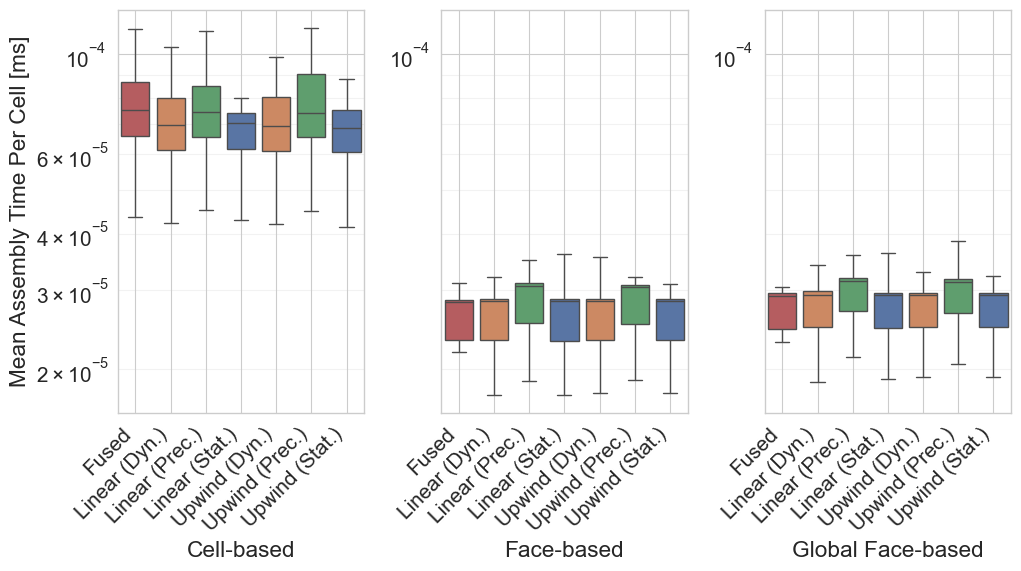

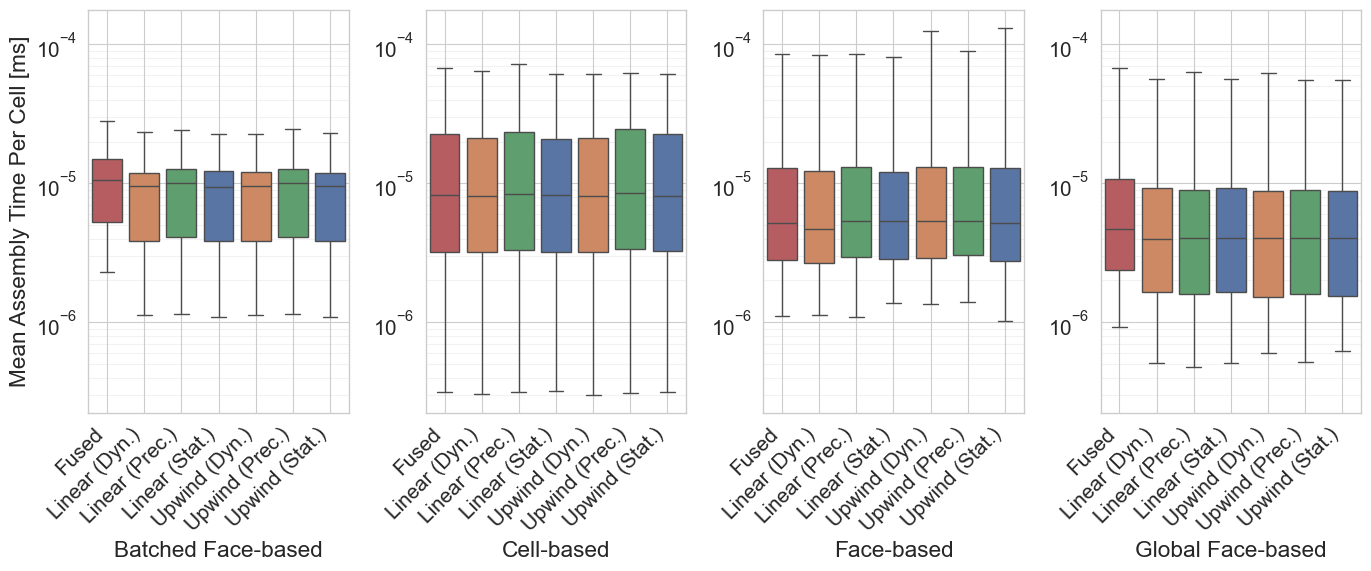

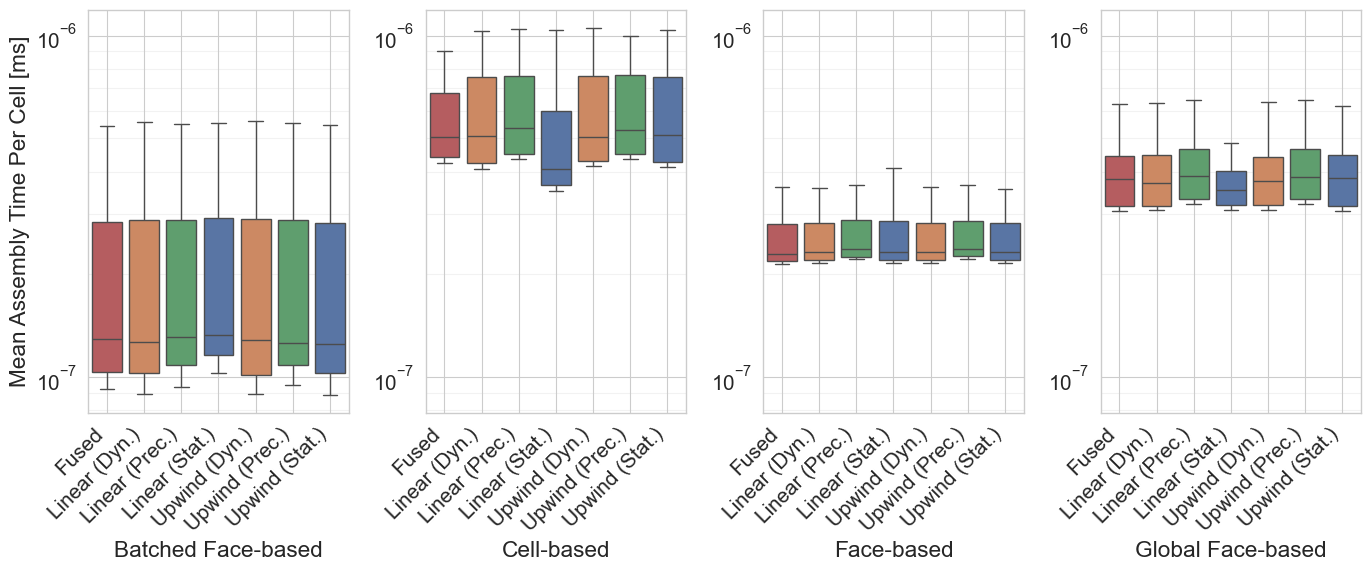

In [216]:

def variants(_df, name, plotname):
    sb.set_style("whitegrid")
    sb.color_palette("deep", 8)
    with sb.plotting_context("paper", font_scale=1.7):
        strategies = sorted(_df["strategy"].unique()) 
        fig, axes = plt.subplots(1,len(strategies), figsize=(len(strategies)*3.5,6), sharey=True)
        for i, ax in enumerate(axes.flat):
            strat = strategies[i]
            case_df = _df[_df["strategy"] == strat]
            plot = sb.boxplot(data=case_df, ax=ax, x="varDisplay", y="ms_normed", log_scale=False, hue="varType", legend=False, showfliers=False, order=sorted_variants)
            plot.set_xticklabels(plot.get_xticklabels(), 
                                rotation=45, 
                                horizontalalignment='right'
            )
            plot.set(
                ylabel="Mean Assembly Time Per Cell [ms]",
            )
            plot.set(xlabel=S[strat])
            ax.yaxis.set_tick_params(labelleft=True)
            ax.set_yscale("log")
            # ax.yaxis.set_minor_locator(LogLocator(base=10, subs=(2, 3, 4, 5, 6, 7, 8, 9)))
            # ax.yaxis.set_minor_formatter(NullFormatter())
            ax.grid(True, which="major", axis="y")
            ax.grid(True, which="minor", axis="y", alpha=0.25)
            ax.grid(True, which="major", axis="x")
        plt.tight_layout()
        plt.savefig(f"variants_{name}_{plotname}.svg")
variants(serial, "cpu", "serial")
variants(cpu[cpu["Threads"]>1], "cpu", "multithread")
variants(df, "gpu", "")



/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_75104/3871832892.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_75104/3871832892.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_75104/3871832892.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_75104/3871832892.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xtic

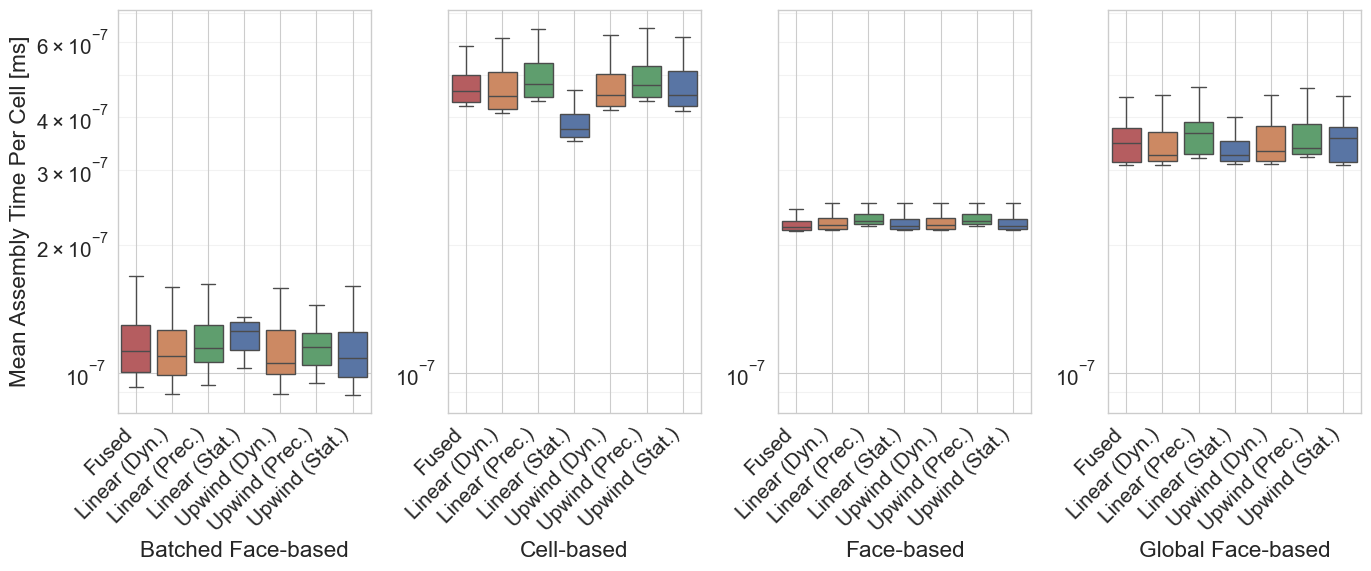

In [217]:
variants(df[df["cells"] >  1000000], "gpu", "max")


/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_75104/3356857372.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_75104/3356857372.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_75104/3356857372.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),


[variants_bw] writing into variants_cpu_serial.svg


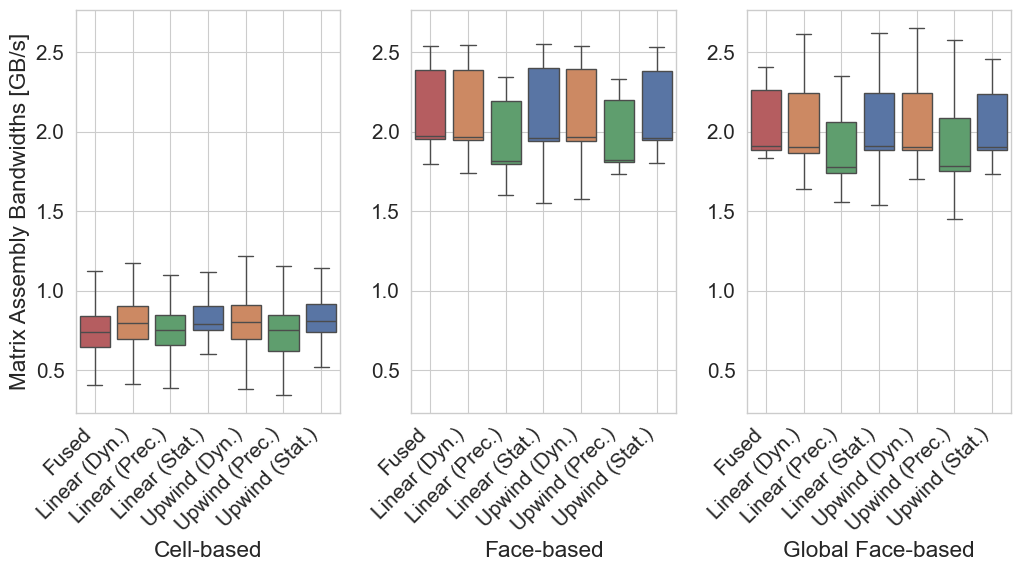

In [218]:

def variants_bw(_df, name, plotname):
    sb.set_style("whitegrid")
    sb.color_palette("deep", 8)
    with sb.plotting_context("paper", font_scale=1.7):
        strategies = sorted(_df["strategy"].unique()) 
        fig, axes = plt.subplots(1,len(strategies), figsize=(len(strategies)*3.5,6), sharey=True)
        for i, ax in enumerate(axes.flat):
            strat = strategies[i]
            case_df = _df[_df["strategy"] == strat]
            plot = sb.boxplot(data=case_df, ax=ax, x="varDisplay", y="bandwidth", log_scale=False, hue="varType", legend=False, showfliers=False, order=sorted_variants)
            plot.set_xticklabels(plot.get_xticklabels(), 
                                rotation=45, 
                                horizontalalignment='right'
            )
            plot.set(
                ylabel="Matrix Assembly Bandwidths [GB/s]",
            )
            plot.set(xlabel=S[strat])
            ax.yaxis.set_tick_params(labelleft=True)
            ax.grid(True)
            # ax.set_yscale("log")
        plt.tight_layout()
        print(f"[variants_bw] writing into variants_{name}_{plotname}.svg")
        plt.savefig(f"variants_{name}_{plotname}.svg")
# variants_bw(cpu[cpu["node"] == "H100"], "cpu", "parallel")
# variants_bw(cpu[cpu["node"] == "H200"], "cpu", "parallel")
variants_bw(serial, "cpu", "serial")



writing into normed_gpu.svg
writing into normed_gpu.svg


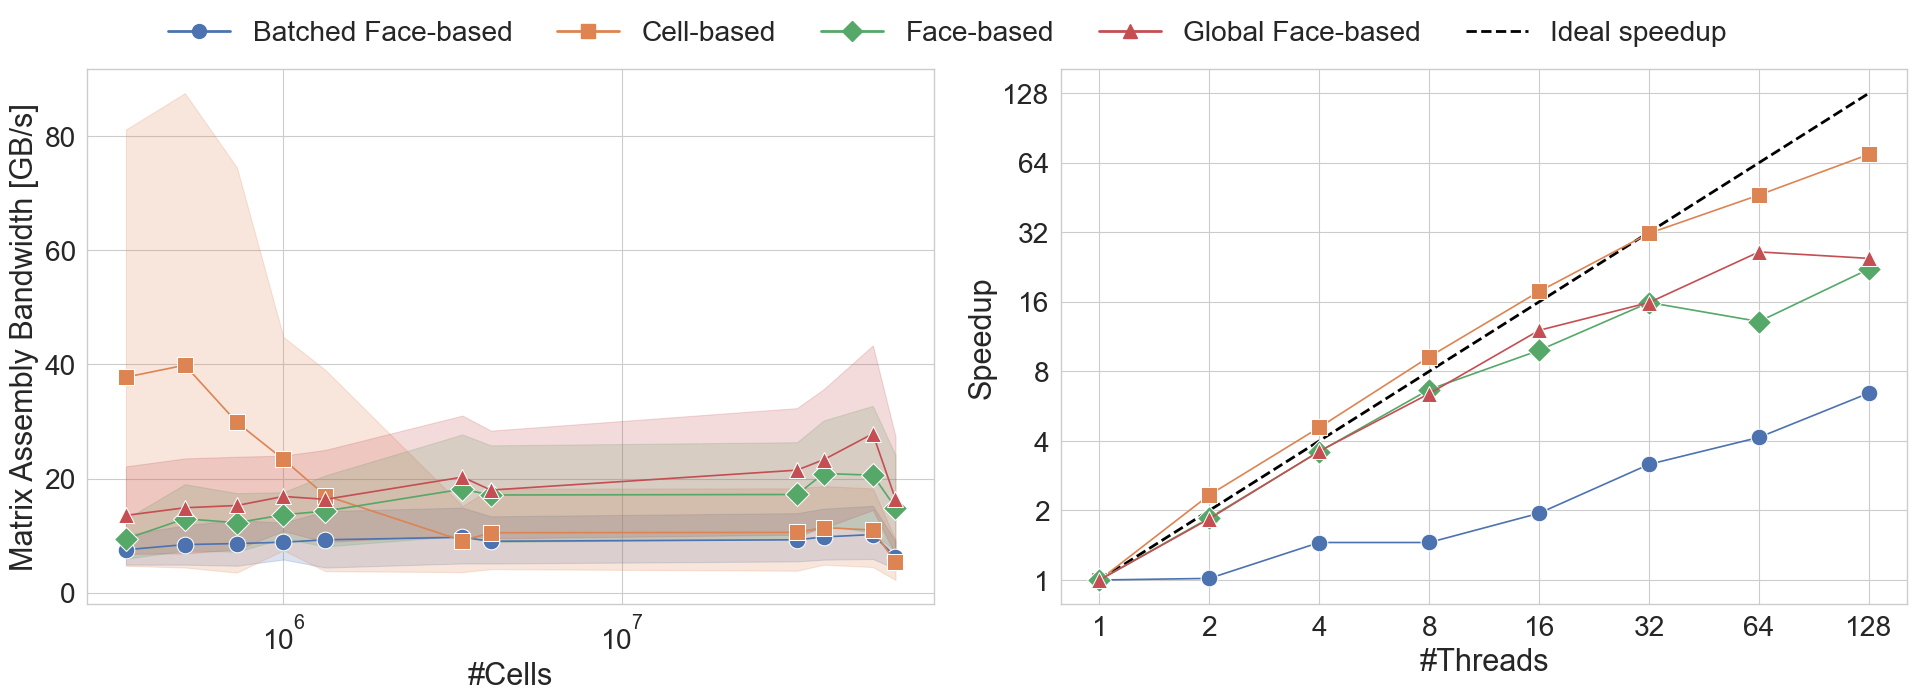

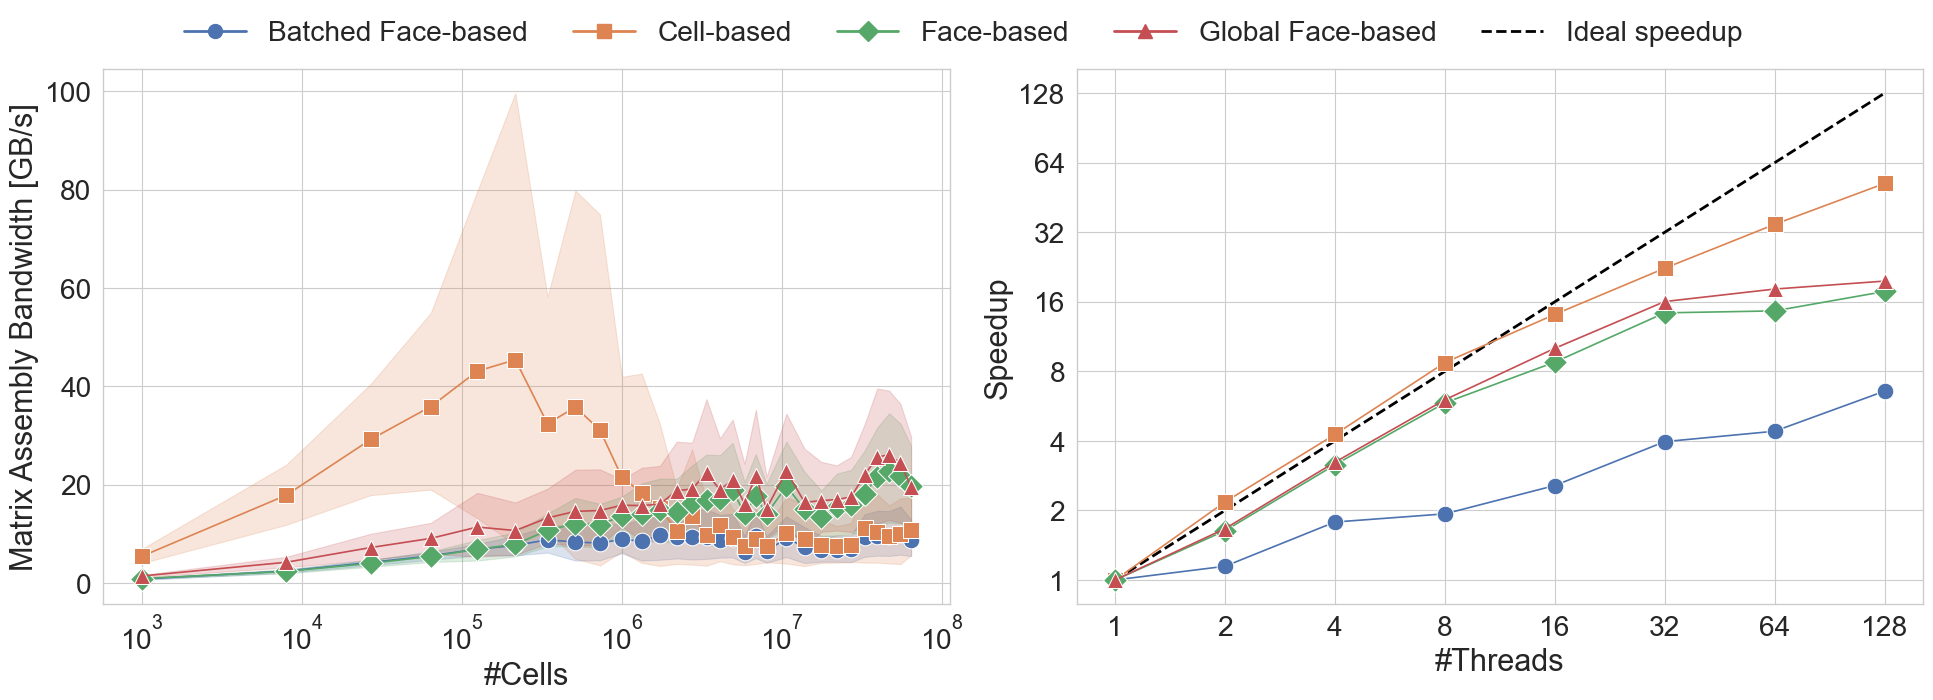

In [219]:

def normed_speedup(_df):
    # _df["dims"] = _df["cells"].apply(lambda x: int(x**(1/3)))
    # dims = sorted(_df["dims"].unique())
    sb.set_theme(rc={'figure.figsize':(20, 7)})
    sb.set_style("whitegrid")
    sb.color_palette("deep", 8)
    order = sorted(_df["s_display"].unique())
    palette = dict(zip(order, sb.color_palette("deep", n_colors=len(order))))
    marker_symbols = ["o", "s", "D", "^", "v", "P", "X", "*"]
    markers = {strategy: marker_symbols[i % len(marker_symbols)] for i, strategy in enumerate(order)}
    plot_df = _df.copy()
    serial_baseline_df = serial[
        serial["cells"].isin(plot_df["cells"].unique())
        & serial["strategy"].isin(plot_df["strategy"].unique())
        & serial["variant"].isin(plot_df["variant"].unique())
    ].copy()
    serial_baseline_df["node"] = plot_df["node"].iloc[0]
    serial_baseline_df["speedup"] = 1.0
    batched_baseline_df = plot_df[
        (plot_df["strategy"] == "batchedFace")
        & (plot_df["Threads"] == plot_df["Threads"].min())
    ].copy()
    batched_baseline_df["Threads"] = 1
    batched_baseline_df["speedup"] = 1.0
    baseline_df = pd.concat(
        [serial_baseline_df, batched_baseline_df],
        ignore_index=True,
    ).reindex(columns=plot_df.columns)
    speedup_plot_df = pd.concat([baseline_df, plot_df], ignore_index=True)
    thread_values = sorted(speedup_plot_df["Threads"].dropna().unique())
    thread_positions = {thread: i for i, thread in enumerate(thread_values)}
    speedup_plot_df["thread_pos"] = speedup_plot_df["Threads"].map(thread_positions)
    
    with sb.plotting_context("paper", font_scale=2.3):
        fig, a= plt.subplots(1, 2)
        axes = a.flat

        p = sb.lineplot(
            data=plot_df,
            x="cells",
            y="bandwidth",
            hue="s_display",
            style="s_display",
            markersize=12,
            hue_order=order,
            style_order=order,
            palette=palette,
            markers=markers,
            # err_style=None,
            dashes=False,
            ax=axes[0]
        )
        p.set(
            ylabel="Matrix Assembly Bandwidth [GB/s]",
            xlabel="#Cells",
            # yscale="log",
            xscale="log",
            # xticks=dims,
            # xticklabels=sorted(_df["cells"].unique())
            # xscale="log",
        )
        p = sb.lineplot(
            data=speedup_plot_df[speedup_plot_df["cells"] >= 20000000],
            x="thread_pos",
            y="speedup",
            hue="s_display",
            style="s_display",
            hue_order=order,
            style_order=order,
            palette=palette,
            markers=markers,
            err_style=None,
            markersize=12,
            dashes=False,
            ax=axes[1]
        )
        p.set(
            ylabel="Speedup",
            xlabel="#Threads",
            yscale="log",
            # xscale="log",
            # xticks=dims,
            # xticklabels=sorted(_df["cells"].unique())
            # xscale="log",
        )
        p.set_xticks(list(thread_positions.values()))
        p.set_xticklabels([str(int(thread)) for thread in thread_values])
        p.set_yticks(thread_values)
        p.set_yticklabels([str(int(thread)) for thread in thread_values])
        # p.set_xlim(min(thread_positions.values()), max(thread_positions.values()))
        p.plot(
            list(thread_positions.values()),
            thread_values,
            color="black",
            linestyle="--",
            linewidth=2,
            label="Ideal Speedup",
            zorder=1,
        )
        handles = [Line2D([0], [0], color=palette[strategy], marker=markers[strategy], linestyle="-", markersize=10, linewidth=2, label=strategy) for strategy in order]
        handles.append(Line2D([0], [0], color="black", linestyle="--", linewidth=2, label="Ideal speedup"))
        labels = order + ["Ideal speedup"]
        for ax in axes:
            leg = ax.get_legend()
            if leg is not None:
                leg.remove()

        # # One shared legend above all subplots, 4 columns
        fig.legend(
            handles,
            labels,
            loc="upper center",
            bbox_to_anchor=(0.5, 0.98),
            ncol=5,
            columnspacing=1.6,
            handlelength=2.2,
            # title="Fused Strategy",
            frameon=False,
        )
        # plt.tight_layout()
        fig.subplots_adjust(
            left=0.07,
            right=0.98,
            # bottom=0.18,
            top=0.875,
            wspace=0.15,
        )
        print(f"writing into normed_gpu.svg")
        plt.savefig(f"bandwidth-speedup.svg")

normed_speedup(cpu[(cpu["variant"] == "Fused") & (cpu["node"] == "H100")])
normed_speedup(cpu[(cpu["variant"] == "Fused") & (cpu["node"] == "H200")])

# normed(df[df["variant"] == "Fused"])


writing into speedup-cpu-H100.svg
writing into speedup-cpu-H200.svg


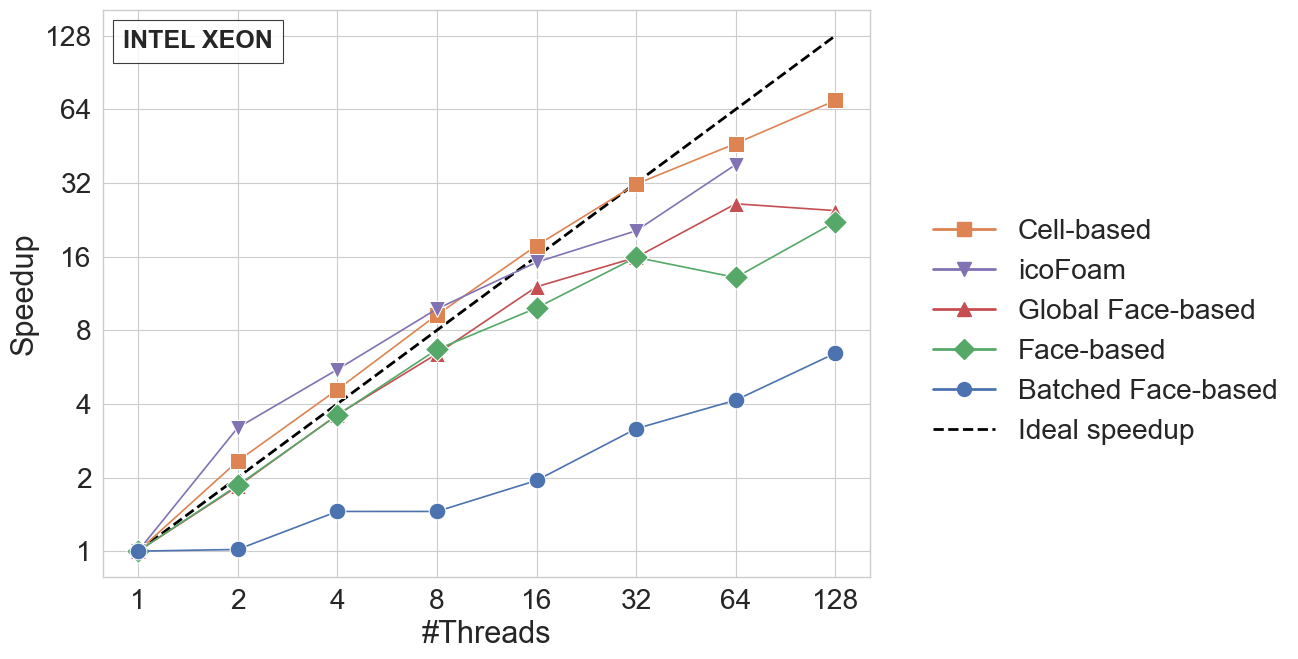

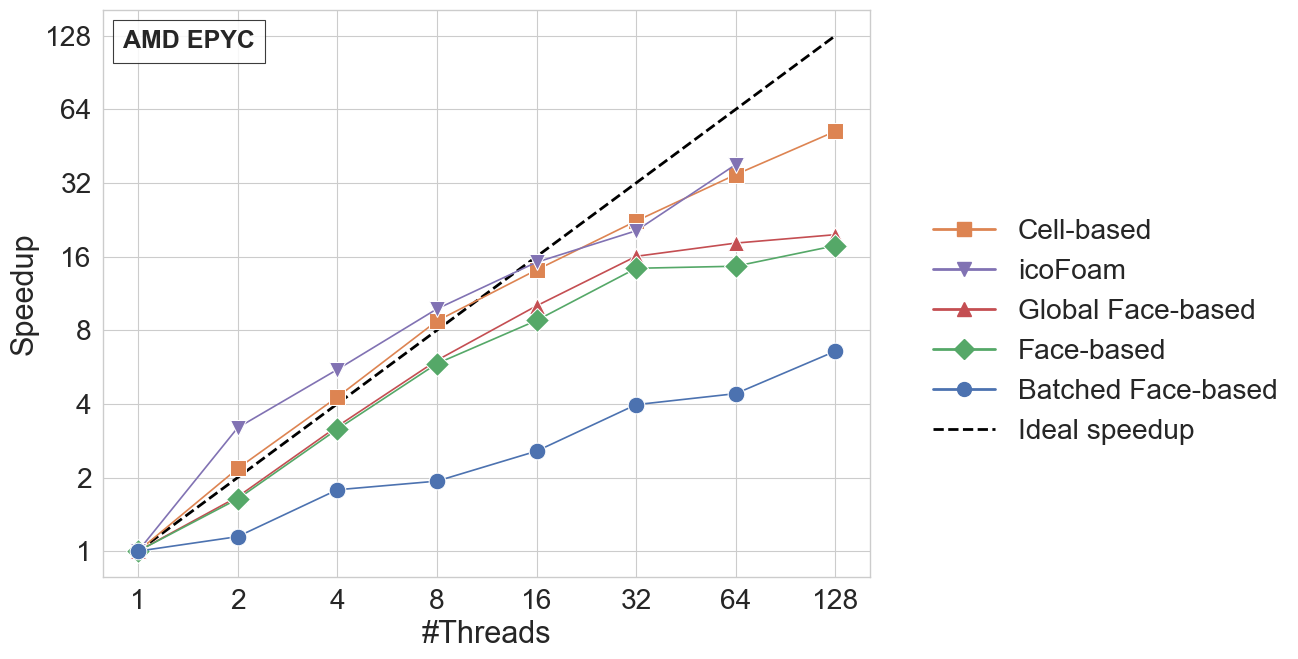

In [220]:

def speedup_subplot(_df, name, cpu_name):
    sb.set_theme(rc={'figure.figsize': (13, 7)})
    sb.set_style("whitegrid")
    sb.color_palette("deep", 8)
    color_order = sorted(list(_df["s_display"].unique()) + ["icoFoam"])
    palette = dict(zip(color_order, sb.color_palette("deep", n_colors=len(color_order))))
    marker_symbols = ["o", "s", "D", "^", "v", "P", "X", "*"]
    markers = {strategy: marker_symbols[i % len(marker_symbols)] for i, strategy in enumerate(color_order)}
    plot_df = _df.copy()
    serial_baseline_df = serial[
        serial["cells"].isin(plot_df["cells"].unique())
        & serial["strategy"].isin(plot_df["strategy"].unique())
        & serial["variant"].isin(plot_df["variant"].unique())
    ].copy()
    serial_baseline_df["node"] = plot_df["node"].iloc[0]
    serial_baseline_df["speedup"] = 1.0
    batched_baseline_df = plot_df[
        (plot_df["strategy"] == "batchedFace")
        & (plot_df["Threads"] == plot_df["Threads"].min())
    ].copy()
    batched_baseline_df["Threads"] = 1
    batched_baseline_df["speedup"] = 1.0
    baseline_df = pd.concat(
        [serial_baseline_df, batched_baseline_df],
        ignore_index=True,
    ).reindex(columns=plot_df.columns)
    icofoam_plot_df = icofoam.copy()
    if "cell_dim" in icofoam_plot_df.columns:
        icofoam_plot_df["cells"] = pd.to_numeric(icofoam_plot_df["cell_dim"], errors="raise").astype(int) ** 3
    else:
        icofoam_plot_df["cells"] = pd.to_numeric(icofoam_plot_df["cells"], errors="raise").astype(int)
    icofoam_plot_df["nprocs"] = pd.to_numeric(icofoam_plot_df["nprocs"], errors="raise").astype(int)
    icofoam_plot_df["time_s"] = pd.to_numeric(icofoam_plot_df["time_s"], errors="raise")
    icofoam_baseline_nprocs = int(icofoam_plot_df["nprocs"].min())
    icofoam_baseline = (
        icofoam_plot_df[icofoam_plot_df["nprocs"] == icofoam_baseline_nprocs]
        .groupby("cells", as_index=False)["time_s"]
        .mean()
        .rename(columns={"time_s": "baseline_time_s"})
    )
    icofoam_plot_df = icofoam_plot_df.merge(icofoam_baseline, on="cells", how="inner")
    icofoam_plot_df["speedup"] = icofoam_plot_df["baseline_time_s"] * icofoam_baseline_nprocs / icofoam_plot_df["time_s"]
    icofoam_plot_df["Threads"] = icofoam_plot_df["nprocs"]
    icofoam_plot_df["s_display"] = "icoFoam"
    speedup_plot_df = pd.concat([baseline_df, plot_df, icofoam_plot_df], ignore_index=True, sort=False)
    thread_values = sorted(speedup_plot_df["Threads"].dropna().unique())
    thread_positions = {thread: i for i, thread in enumerate(thread_values)}
    speedup_plot_df["thread_pos"] = speedup_plot_df["Threads"].map(thread_positions)
    speedup_data = speedup_plot_df[speedup_plot_df["cells"] >= 20000000].copy()
    right_edge = speedup_data.groupby("s_display")["thread_pos"].transform("max")
    terminal_values = (
        speedup_data[speedup_data["thread_pos"].eq(right_edge)]
        .groupby("s_display")["speedup"]
        .mean()
        .sort_values(ascending=False)
    )
    order = terminal_values.index.tolist()
    order += [strategy for strategy in color_order if strategy not in order]

    with sb.plotting_context("paper", font_scale=2.3):
        fig, ax = plt.subplots(1, 1, figsize=(13, 7))
        p = sb.lineplot(
            data=speedup_data,
            x="thread_pos",
            y="speedup",
            hue="s_display",
            style="s_display",
            hue_order=order,
            style_order=order,
            palette=palette,
            markers=markers,
            err_style=None,
            markersize=12,
            dashes=False,
            ax=ax,
        )
        p.set(
            ylabel="Speedup",
            xlabel="#Threads",
            yscale="log",
        )
        p.set_xticks(list(thread_positions.values()))
        p.set_xticklabels([str(int(thread)) for thread in thread_values])
        p.set_yticks(thread_values)
        p.set_yticklabels([str(int(thread)) for thread in thread_values])
        p.plot(
            list(thread_positions.values()),
            thread_values,
            color="black",
            linestyle="--",
            linewidth=2,
            label="Ideal Speedup",
            zorder=1,
        )
        cpu_box = AnchoredText(
            cpu_name,
            loc="upper left",
            prop={"size": 18, "weight": "bold"},
            frameon=True,
            borderpad=0.4,
        )
        cpu_box.patch.set_alpha(0.85)
        ax.add_artist(cpu_box)
        handles = [Line2D([0], [0], color=palette[strategy], marker=markers[strategy], linestyle="-", markersize=10, linewidth=2, label=strategy) for strategy in order]
        handles.append(Line2D([0], [0], color="black", linestyle="--", linewidth=2, label="Ideal speedup"))
        labels = order + ["Ideal speedup"]
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()

        fig.legend(
            handles,
            labels,
            loc="center left",
            bbox_to_anchor=(0.73, 0.5),
            ncol=1,
            handlelength=2.2,
            borderaxespad=0.0,
            frameon=False,
        )
        fig.subplots_adjust(
            left=0.10,
            right=0.69,
            bottom=0.15,
            top=0.96,
        )
        print(f"writing into speedup-{name}.svg")
        plt.savefig(f"speedup-{name}.svg")
        # plt.close(fig)

speedup_subplot(cpu[(cpu["variant"] == "Fused") & (cpu["node"] == "H100")], "cpu-H100", "INTEL XEON")
speedup_subplot(cpu[(cpu["variant"] == "Fused") & (cpu["node"] == "H200")], "cpu-H200", "AMD EPYC")


In [221]:
cpu["cells"].unique()

array([ 1000000,   343000,  3375000, 39304000,   512000,  4096000,
         729000,  1331000, 54872000, 32768000, 64000000,    27000,
       21952000,    64000,  8000000,     1000, 27000000,     8000,
        5832000, 17576000, 13824000,   125000, 10648000,  6859000,
       46656000,  2744000,  1728000,  2197000,   216000,  4913000])

writing into normed_gpu.svg
writing into normed_gpu.svg
writing into normed_gpu.svg


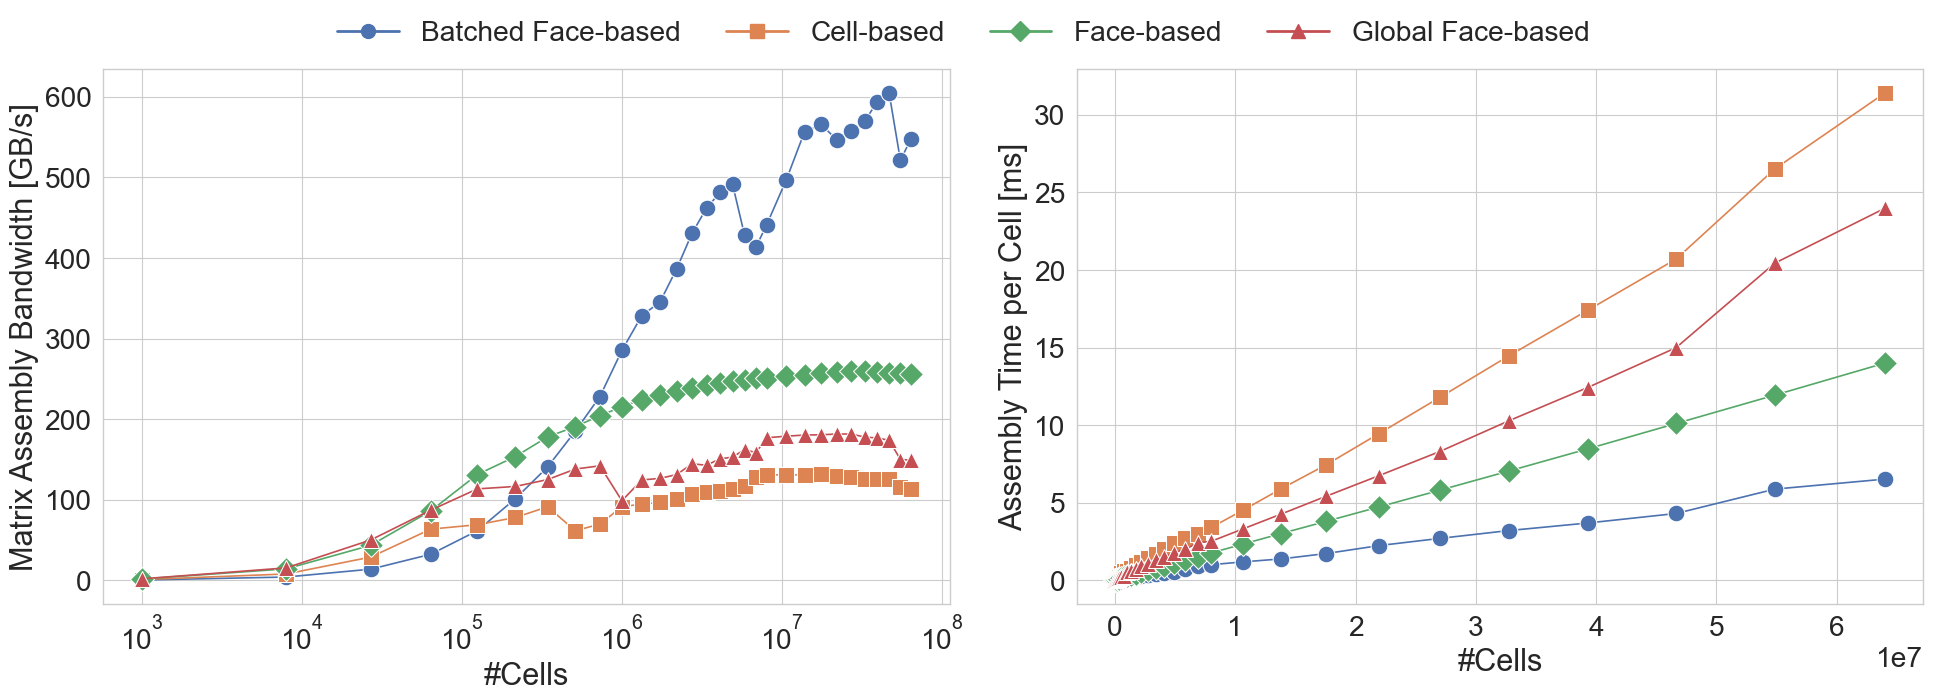

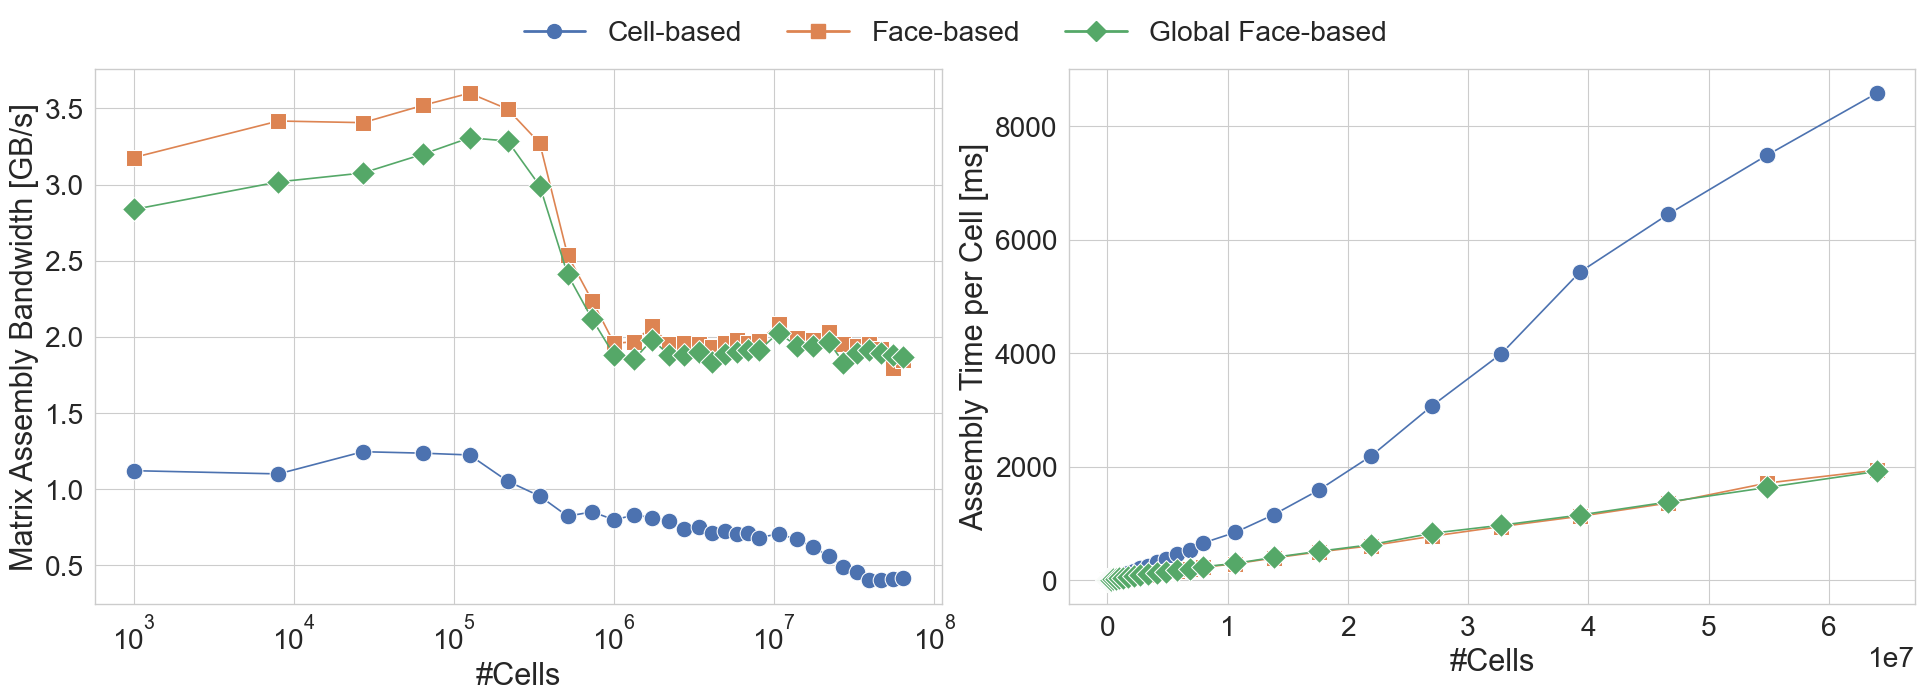

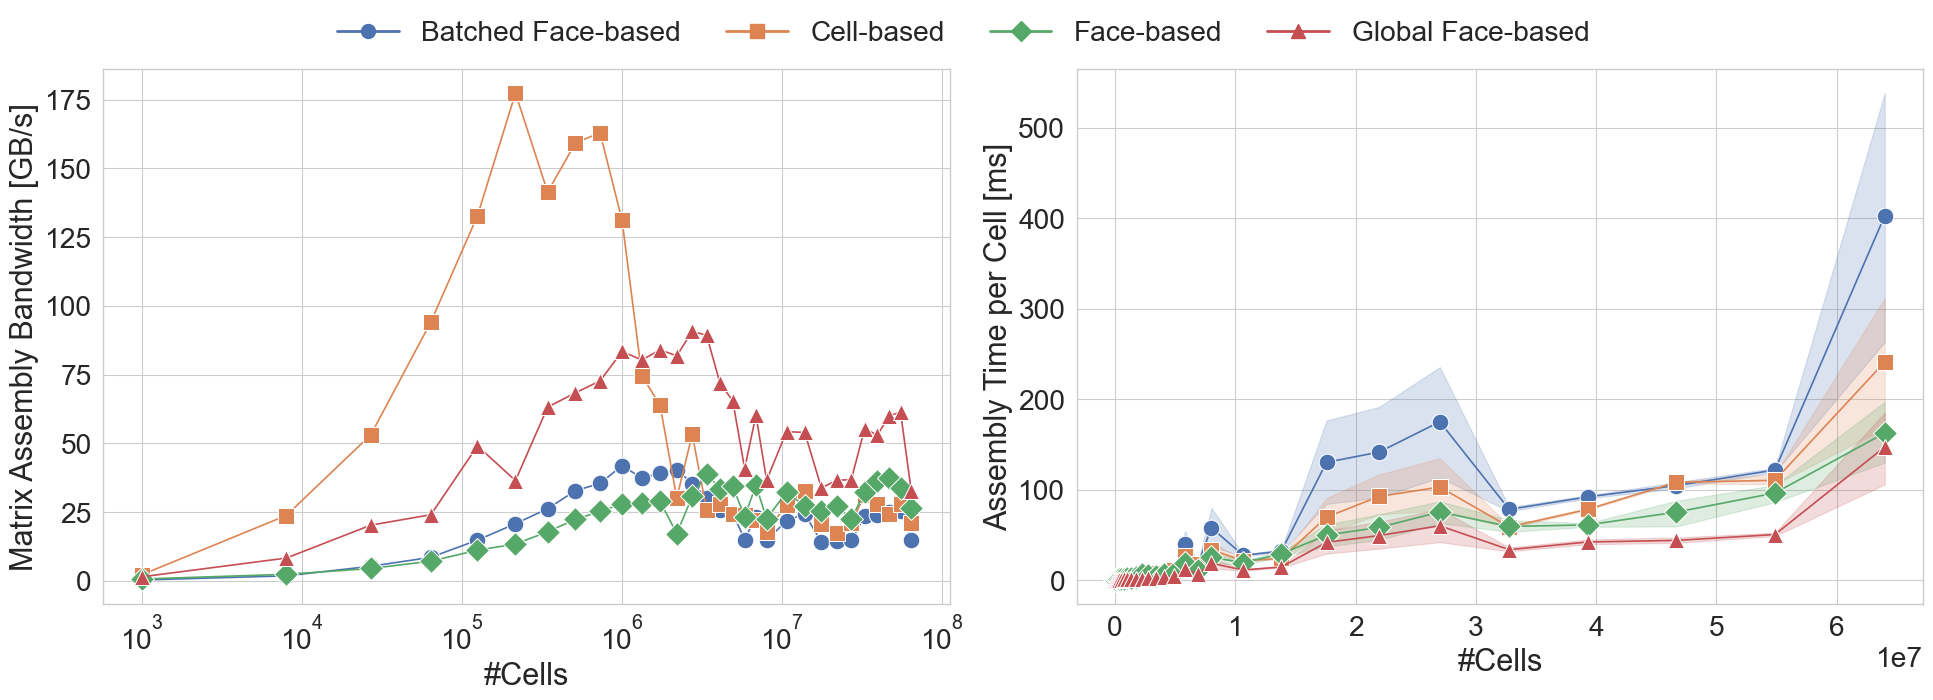

In [222]:

def normed(_df):
    # _df["dims"] = _df["cells"].apply(lambda x: int(x**(1/3)))
    # dims = sorted(_df["dims"].unique())
    sb.set_theme(rc={'figure.figsize':(20, 7)})
    sb.set_style("whitegrid")
    sb.color_palette("deep", 8)
    order = sorted(_df["s_display"].unique())
    palette = dict(zip(order, sb.color_palette("deep", n_colors=len(order))))
    marker_symbols = ["o", "s", "D", "^", "v", "P", "X", "*"]
    markers = {strategy: marker_symbols[i % len(marker_symbols)] for i, strategy in enumerate(order)}
    exec = list(_df["executor"].unique())[0]
    suffix = ""
    if exec == "cpu":
        if len(_df["Threads"].unique()) > 1:
            suffix = "-multithreaded"
        else:
            suffix = "-serial"
    with sb.plotting_context("paper", font_scale=2.3):
        fig, a= plt.subplots(1, 2)
        axes = a.flat

        p = sb.lineplot(
            data=_df,
            x="cells",
            y="bandwidth",
            hue="s_display",
            style="s_display",
            markersize=12,
            hue_order=order,
            style_order=order,
            palette=palette,
            markers=markers,
            err_style=None,
            dashes=False,
            ax=axes[0]
        )
        p.set(
            ylabel="Matrix Assembly Bandwidth [GB/s]",
            xlabel="#Cells",
            # yscale="log",
            xscale="log",
            # xticks=dims,
            # xticklabels=sorted(_df["cells"].unique())
            # xscale="log",
        )
        p = sb.lineplot(
            data=_df,
            x="cells",
            y="time_mean_ms",
            hue="s_display",
            style="s_display",
            hue_order=order,
            style_order=order,
            palette=palette,
            markers=markers,
            markersize=12,
            dashes=False,
            ax=axes[1]
        )
        p.set(
            ylabel="Assembly Time per Cell [ms]",
            xlabel="#Cells",
            # yscale="log",
            # xscale="log",
            # xticks=dims,
            # xticklabels=sorted(_df["cells"].unique())
            # xscale="log",
        )
        handles = [Line2D([0], [0], color=palette[strategy], marker=markers[strategy], linestyle="-", markersize=10, linewidth=2, label=strategy) for strategy in order]
        labels = order
        for ax in axes:
            leg = ax.get_legend()
            if leg is not None:
                leg.remove()

        # # One shared legend above all subplots, 4 columns
        fig.legend(
            handles,
            labels,
            loc="upper center",
            bbox_to_anchor=(0.5, 0.98),
            ncol=4,
            columnspacing=1.6,
            handlelength=2.2,
            # title="Fused Strategy",
            frameon=False,
        )
        # plt.tight_layout()
        fig.subplots_adjust(
            left=0.07,
            right=0.98,
            # bottom=0.18,
            top=0.875,
            wspace=0.15,
        )
        print(f"writing into normed_gpu.svg")
        plt.savefig(f"bandwidt-timenormed-{exec}{suffix}.svg")

# normed(cpu[(cpu["variant"] == "Fused")& (cpu["Threads"]> 1)])

normed(df[df["variant"] == "Fused"])
# normed(serial[(serial["variant"] == "Fused") & (serial["cells"] <= 1000000)])
normed(serial[(serial["variant"] == "Fused")])
normed(cpu[cpu["Threads"] == 128])


writing into normed_gpu.svg


/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_75104/3871832892.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_75104/3871832892.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_75104/3871832892.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_75104/3871832892.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xtic

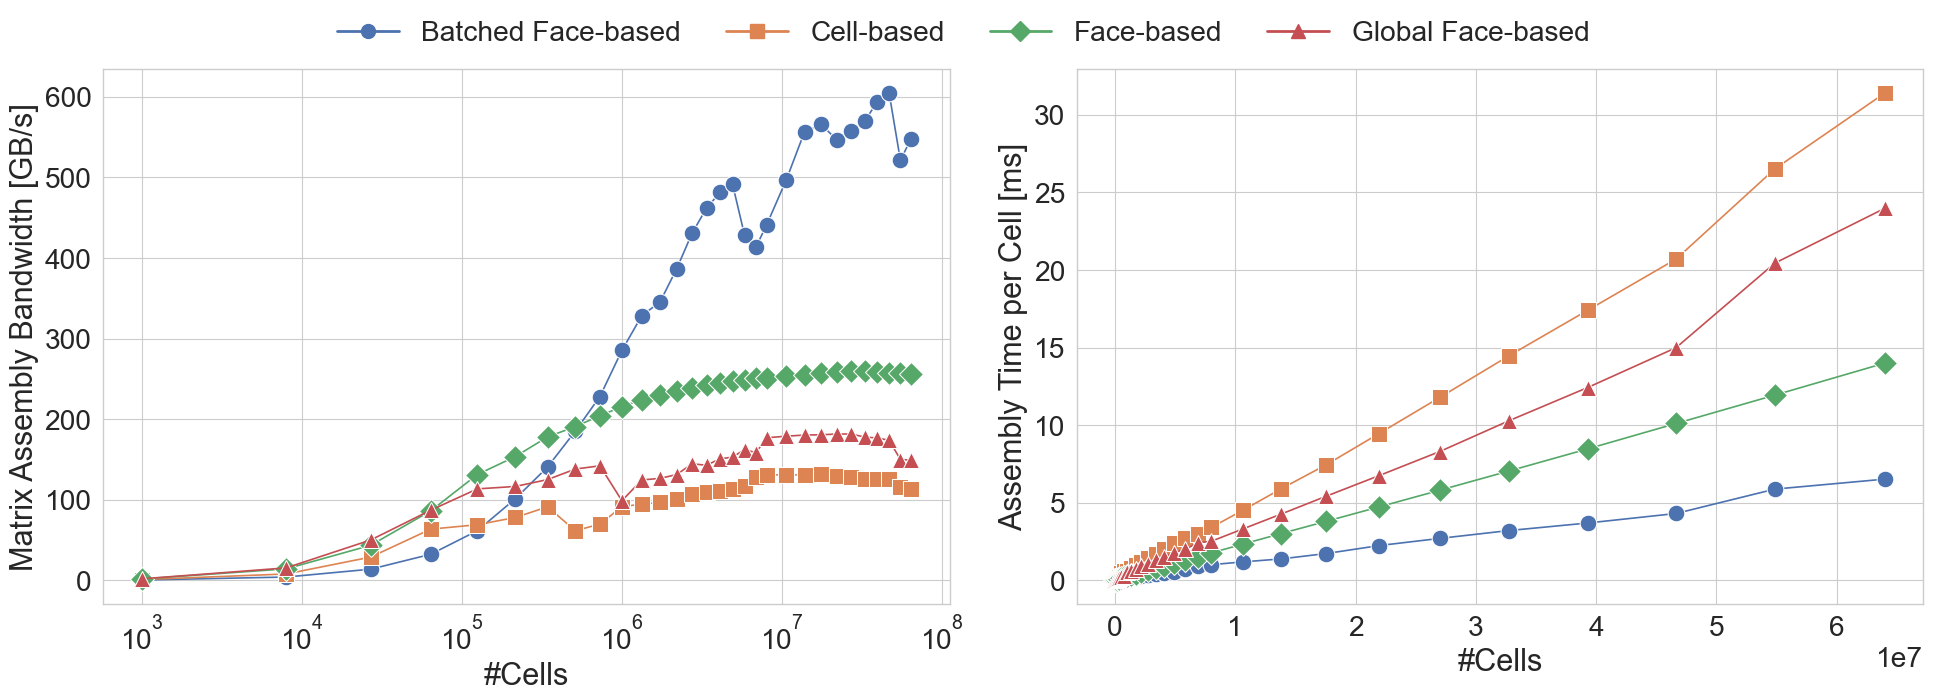

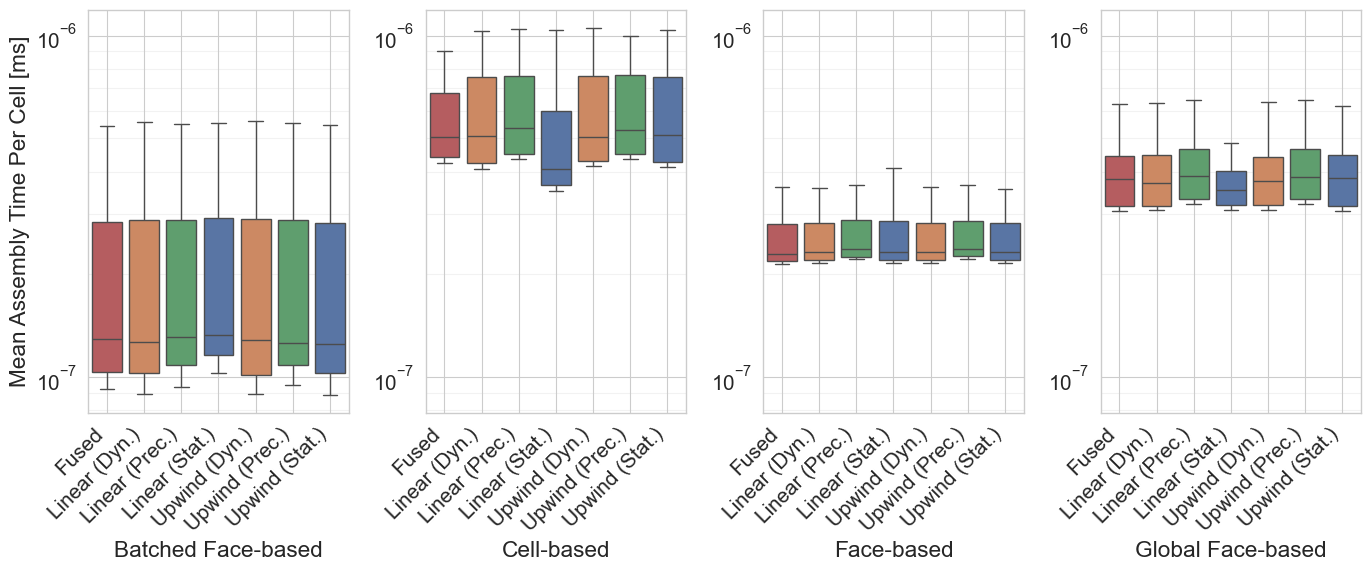

In [223]:

normed(df[df["variant"] == "Fused"])

variants(df, "gpu", "GPU")
# batched = df[df["strategy"] == "batchedFace"]
# batched = batched[batched["variant"] == "Fused"]
# batched.to_csv("batched.csv", index=False)


/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_75104/3356857372.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_75104/3356857372.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_75104/3356857372.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_75104/3356857372.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xtic

[variants_bw] writing into variants_cpu_parallel.svg


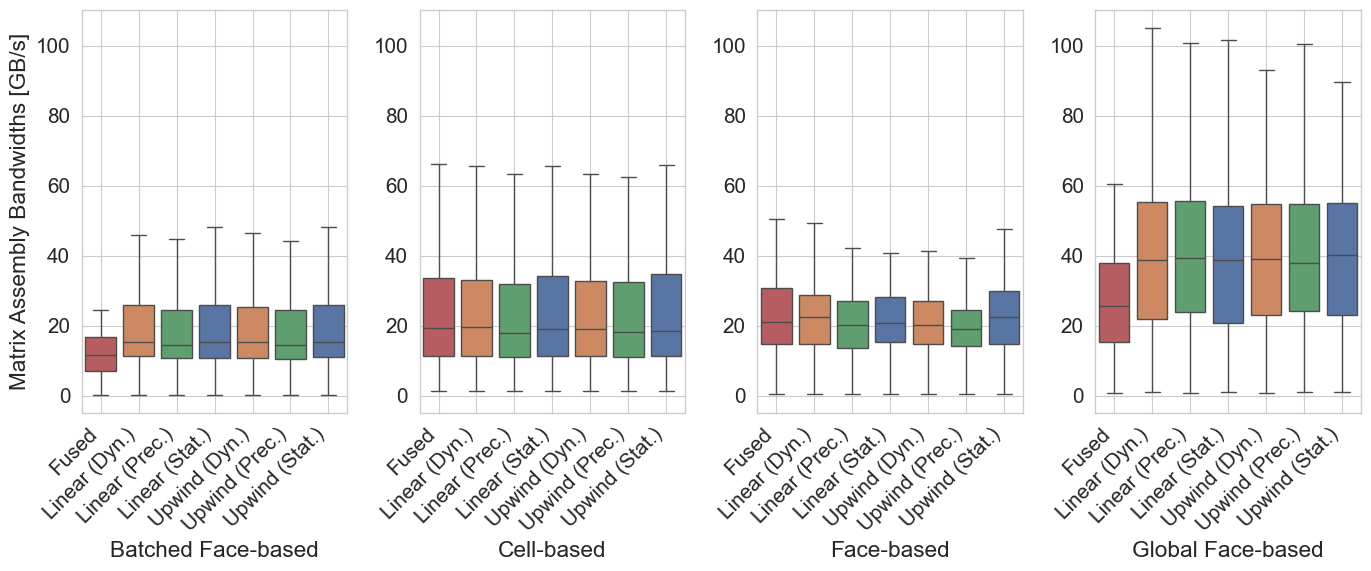

In [224]:
variants_bw(cpu[cpu["Threads"]> 16], "cpu", "parallel")


writing into normed_gpu.svg
writing into normed_gpu.svg


/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_75104/3356857372.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_75104/3356857372.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_75104/3356857372.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_75104/3356857372.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xtic

[variants_bw] writing into variants_cpu_parallel.svg


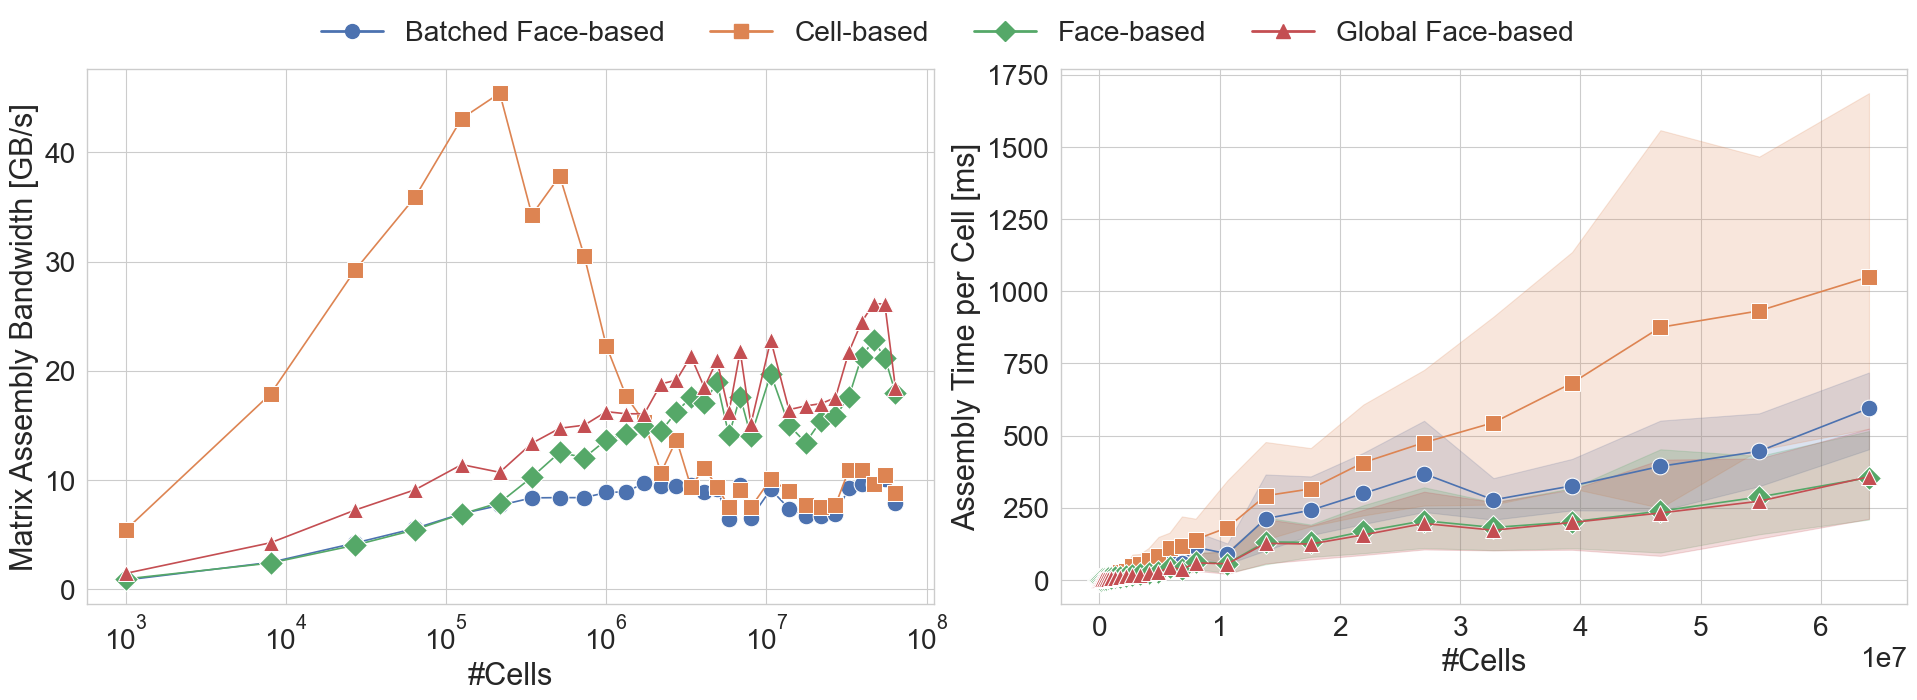

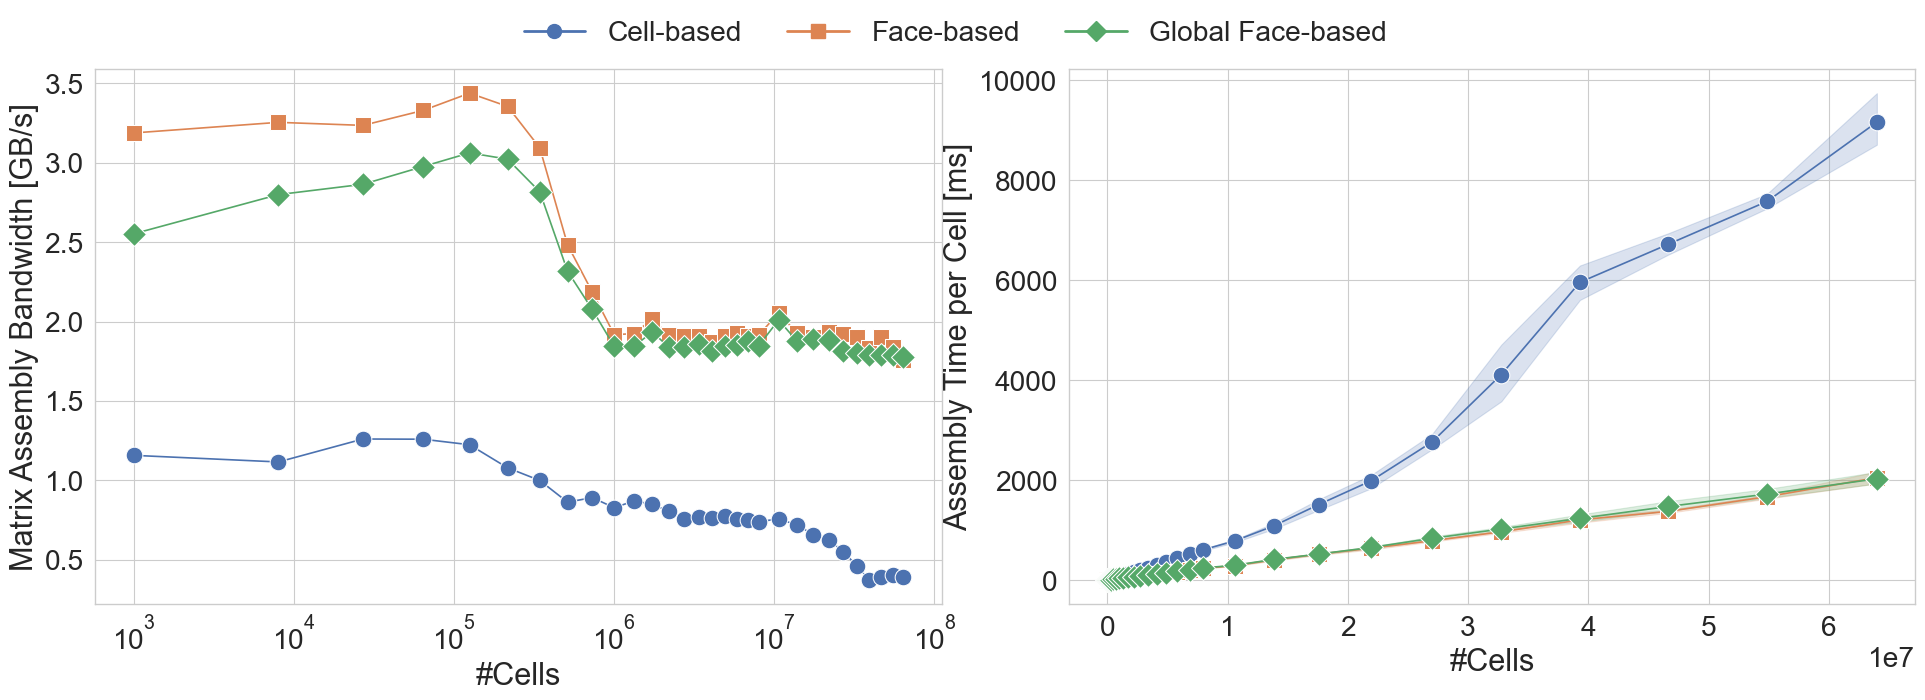

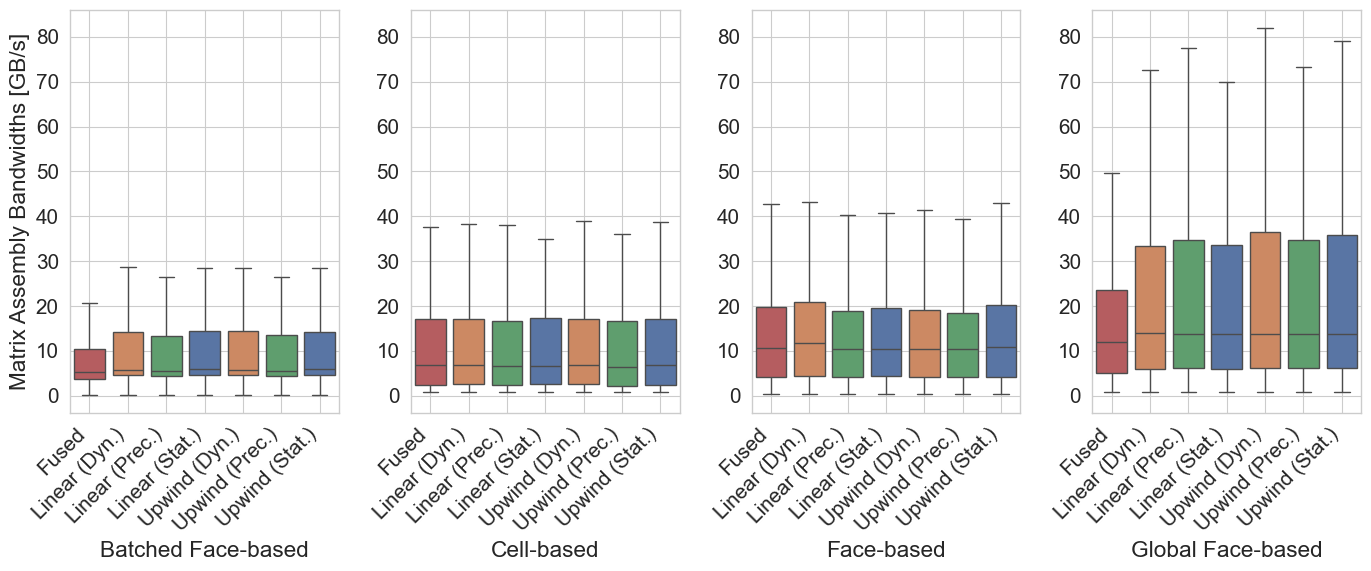

In [225]:
normed(cpu[(cpu["variant"] == "Fused")& (cpu["Threads"]> 1)])
normed(serial)
variants_bw(cpu[cpu["Threads"]> 1], "cpu", "parallel")


/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_75104/3356857372.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_75104/3356857372.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_75104/3356857372.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_75104/3356857372.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xtic

[variants_bw] writing into variants_gpu_parallel.svg


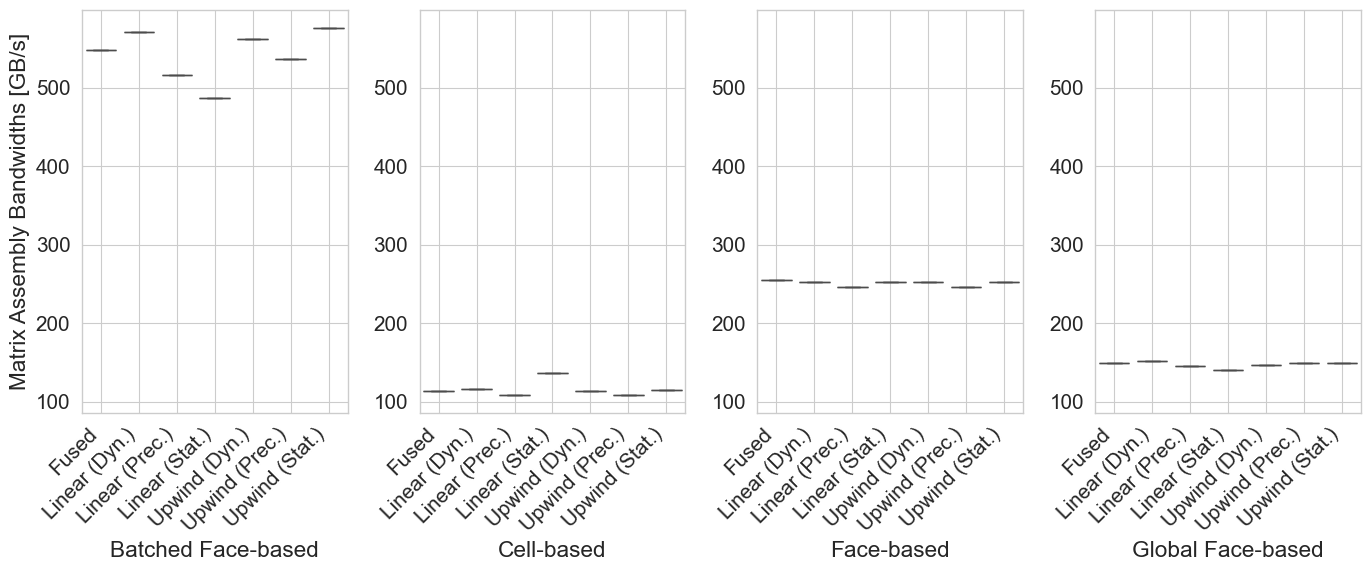

In [226]:
# variants_bw(df, "gpu", "parallel")
variants_bw(df[df["cells"] == 64000000], "gpu", "parallel")


[variants_bw] writing into variants_cpu_parallel.svg


/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_75104/3356857372.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_75104/3356857372.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_75104/3356857372.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_75104/3356857372.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xtic

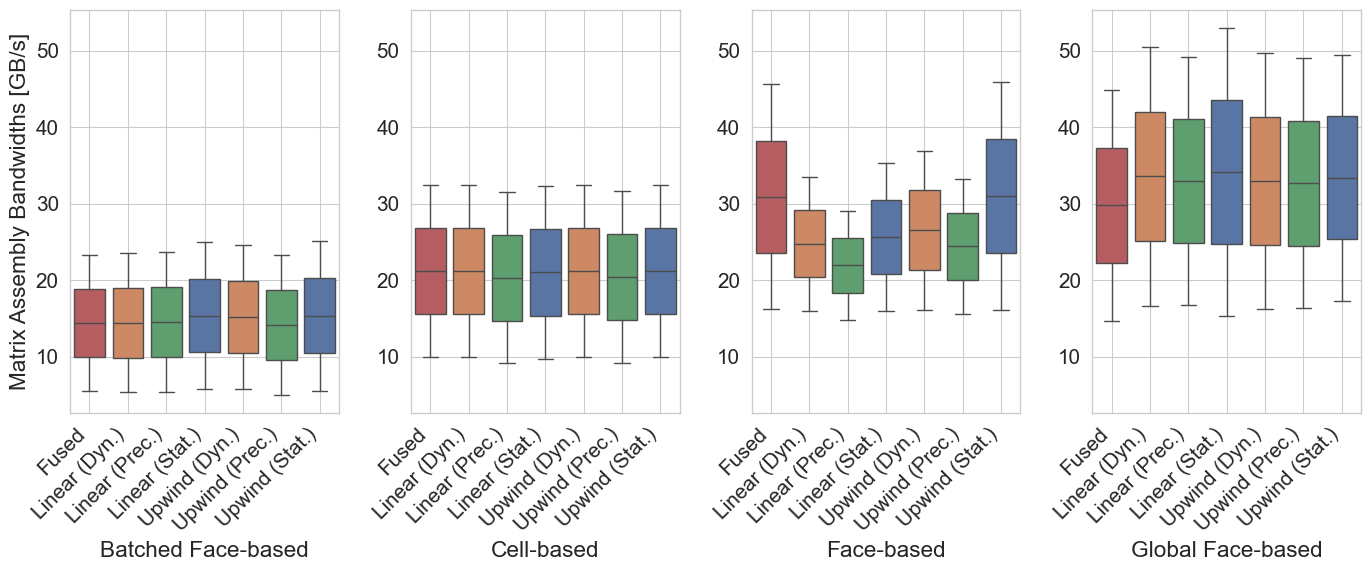

In [227]:
variants_bw(cpu[(cpu["Threads"] ==128) & (cpu["cells"] == 64000000)], "cpu", "parallel")
# variants_bw(df[(df["cells"] == 64000000)], "cpu", "parallel")



In [228]:
df[df["strategy"].str.contains("batch")]

,time_mean_ms,time_median_ms,gc_time_mean_ms,gc_time_median_ms,case_short,case_long,strategy,variant,language,precision,...,use_fusing,Threads,nnz,cells,s_display,ms_normed,ns_normed,varDisplay,varType,bandwidth
7,0.099846,0.098179,0.000715,0.0,LDC-1000,LDC-1000,batchedFace,HardCodedCDF,julia,float64,...,True,1,6400,1000,Batched Face-based,9.984619e-05,99.846191,Linear (Stat.),Hardcoded,0.512789
8,0.103517,0.101904,0.000726,0.0,LDC-1000,LDC-1000,batchedFace,DynamicUpwind,julia,float64,...,True,1,6400,1000,Batched Face-based,1.035170e-04,103.517021,Upwind (Dyn.),Dynamic,0.494605
9,0.101874,0.100342,0.000778,0.0,LDC-1000,LDC-1000,batchedFace,PrecalculatedWeightsUpwind,julia,float64,...,True,1,6400,1000,Batched Face-based,1.018736e-04,101.873639,Upwind (Prec.),Precalculated Weights,0.502583
10,0.103672,0.102113,0.000837,0.0,LDC-1000,LDC-1000,batchedFace,DynamicCDF,julia,float64,...,True,1,6400,1000,Batched Face-based,1.036720e-04,103.671953,Linear (Dyn.),Dynamic,0.493865
11,0.102289,0.100850,0.000821,0.0,LDC-1000,LDC-1000,batchedFace,PrecalculatedWeightsCDF,julia,float64,...,True,1,6400,1000,Batched Face-based,1.022885e-04,102.288530,Linear (Prec.),Precalculated Weights,0.500545
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
618,0.567940,0.567533,0.000000,0.0,LDC-4913000,LDC-4913000,batchedFace,PrecalculatedWeightsUpwind,julia,float64,...,True,1,34217600,4913000,Batched Face-based,1.155994e-07,0.115599,Upwind (Prec.),Precalculated Weights,481.988961
619,0.541710,0.541134,0.000000,0.0,LDC-4913000,LDC-4913000,batchedFace,DynamicCDF,julia,float64,...,True,1,34217600,4913000,Batched Face-based,1.102606e-07,0.110261,Linear (Dyn.),Dynamic,505.327079
620,0.567244,0.566851,0.000000,0.0,LDC-4913000,LDC-4913000,batchedFace,PrecalculatedWeightsCDF,julia,float64,...,True,1,34217600,4913000,Batched Face-based,1.154577e-07,0.115458,Linear (Prec.),Precalculated Weights,482.580574
621,0.538435,0.537991,0.000000,0.0,LDC-4913000,LDC-4913000,batchedFace,HardCodedUpwind,julia,float64,...,True,1,34217600,4913000,Batched Face-based,1.095939e-07,0.109594,Upwind (Stat.),Hardcoded,508.400815


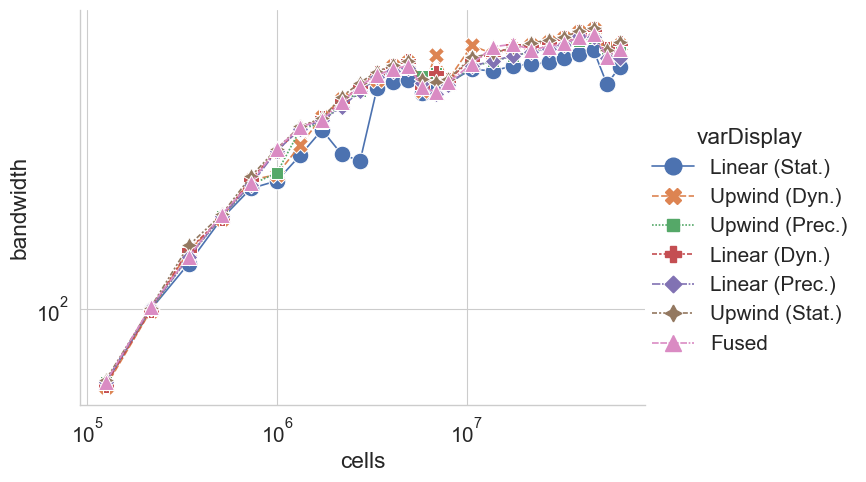

In [229]:

def test(_df, name, plotname):
    sb.set_theme(rc={'figure.figsize':(20, 7)})
    sb.set_style("whitegrid")
    sb.color_palette("deep", 8)
    with sb.plotting_context("paper", font_scale=1.7):
        p = sb.relplot(
            data=_df[_df["cells"] > 100000],
            x = "cells",
            y="bandwidth",
            hue="varDisplay",
            style="varDisplay",
            kind="line",
            aspect=1.4,
            markersize=12,
            markers=True
        )
        p.set(
            yscale="log",
            xscale="log"
        )
        # strategies = sorted(_df["strategy"].unique()) 
        # cells = sorted(_df["cells"].unique()) 
        # print(cells)
        # fig, axes = plt.subplots(1,5, sharey=True)
        # for i, ax in enumerate(axes.flat):
        #     strat = cells[-i]
        #     case_df = _df[_df["cells"] == strat]
        #     plot = sb.boxplot(data=case_df, ax=ax, x="varDisplay", y="bandwidth", log_scale=False, hue="varType", legend=False, showfliers=False, order=sorted_variants)
        #     plot.set_xticklabels(plot.get_xticklabels(), 
        #                         rotation=45, 
        #                         horizontalalignment='right'
        #     )
        #     plot.set(
        #         ylabel="Matrix Assembly Bandwidths [GB/s]",
        #     )
        #     # plot.set(xlabel=f"{strat.capitalize()}")
        #     ax.yaxis.set_tick_params(labelleft=True)
        #     ax.grid(True)
        #     # ax.set_yscale("log")
        # plt.tight_layout()
        # print(f"[variants_bw] writing into variants_{name}_{plotname}.svg")
        # plt.savefig(f"variants_{name}_{plotname}.svg")
# variants_bw(cpu[cpu["node"] == "H100"], "cpu", "parallel")
# variants_bw(cpu[cpu["node"] == "H200"], "cpu", "parallel")
test(df[df["strategy"].str.contains("batch")], "cpu", "serial")



/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_75104/3356857372.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_75104/3356857372.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_75104/3356857372.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_75104/3356857372.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xtic

[variants_bw] writing into variants_gpu_parallel.svg


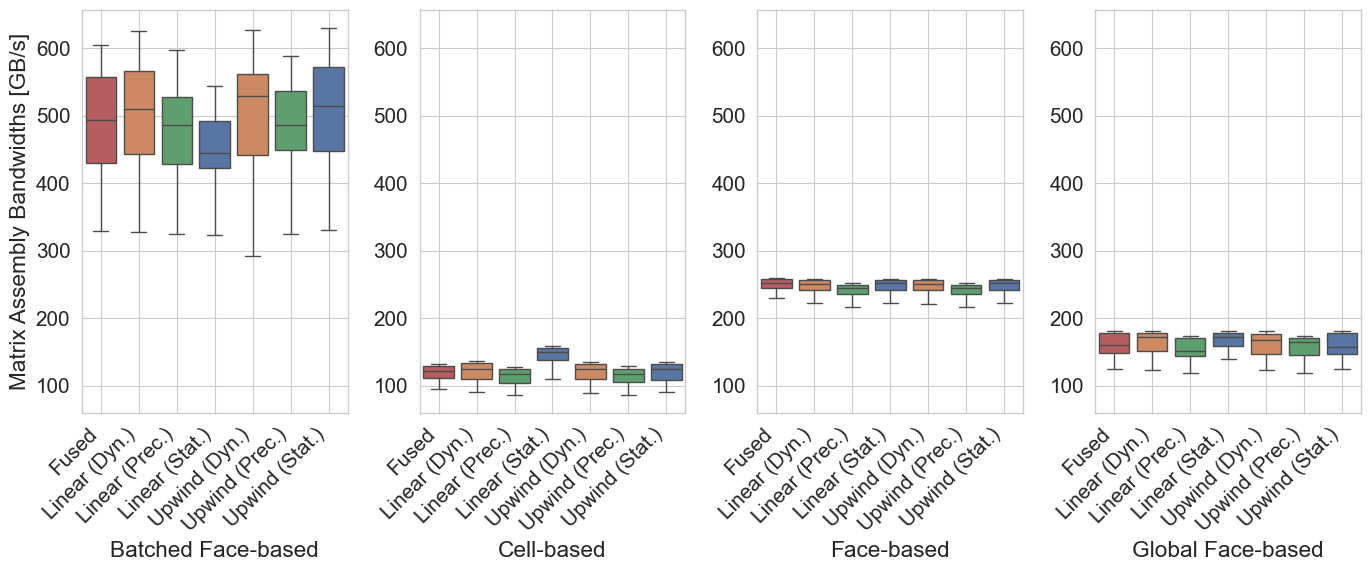

In [230]:
variants_bw(df[df["cells"]> 1000000], "gpu", "parallel")


In [261]:

def splithreads(_df):
    # _df["dims"] = _df["cells"].apply(lambda x: int(x**(1/3)))
    # dims = sorted(_df["dims"].unique())
    sb.set_theme(rc={'figure.figsize':(20, 7)})
    sb.set_style("whitegrid")
    sb.color_palette("deep", 8)
    order = sorted(_df["s_display"].unique())
    palette = dict(zip(order, sb.color_palette("deep", n_colors=len(order))))
    marker_symbols = ["o", "s", "D", "^", "v", "P", "X", "*"]
    markers = {strategy: marker_symbols[i % len(marker_symbols)] for i, strategy in enumerate(order)}
    exec = list(_df["executor"].unique())[0]
    suffix = ""
    if exec == "cpu":
        if len(_df["Threads"].unique()) > 1:
            suffix = "-multithreaded"
        else:
            suffix = "-serial"
    with sb.plotting_context("paper", font_scale=2.3):
        fig, a= plt.subplots(1, 2)
        axes = a.flat
        
        p = sb.relplot(
            data=_df,
            x="cells",
            y="bandwidth",
            hue="Threads",
            style="Threads",
            hue_order=order,
            col="strategy",
            kind="line",

            style_order=order,
            markers=True,
            err_style=None,
            dashes=False,
        )
        p.set(
            ylabel="Matrix Assembly Bandwidth [GB/s]",
            xlabel="#Cells",
            # yscale="log",
            xscale="log",
            # xticks=dims,
            # xticklabels=sorted(_df["cells"].unique())
            # xscale="log",
        )
        # p = sb.lineplot(
        #     data=_df,
        #     x="cells",
        #     y="time_mean_ms",
        #     hue="s_display",
        #     style="s_display",
        #     hue_order=order,
        #     style_order=order,
        #     palette=palette,
        #     markers=markers,
        #     markersize=12,
        #     dashes=False,
        #     ax=axes[1]
        # )
        # p.set(
        #     ylabel="Assembly Time per Cell [ms]",
        #     xlabel="#Cells",
        #     # yscale="log",
        #     # xscale="log",
        #     # xticks=dims,
        #     # xticklabels=sorted(_df["cells"].unique())
        #     # xscale="log",
        # )
        # handles = [Line2D([0], [0], color=palette[strategy], marker=markers[strategy], linestyle="-", markersize=10, linewidth=2, label=strategy) for strategy in order]
        # labels = order
        # for ax in axes:
        #     leg = ax.get_legend()
        #     if leg is not None:
        #         leg.remove()

        # # # One shared legend above all subplots, 4 columns
        # fig.legend(
        #     handles,
        #     labels,
        #     loc="upper center",
        #     bbox_to_anchor=(0.5, 0.98),
        #     ncol=4,
        #     columnspacing=1.6,
        #     handlelength=2.2,
        #     # title="Fused Strategy",
        #     frameon=False,
        # )
        # # plt.tight_layout()
        # fig.subplots_adjust(
        #     left=0.07,
        #     right=0.98,
        #     # bottom=0.18,
        #     top=0.875,
        #     wspace=0.15,
        # )
        print(f"writing into normed_gpu.svg")
        plt.savefig(f"bandwidt-timenormed-{exec}{suffix}.svg")

# normed(cpu[(cpu["variant"] == "Fused")& (cpu["Threads"]> 1)])
sorder = cpu["s_display"].unique()
cpu["mean_bw"] = cpu.groupby(["cells", "variant", "strategy", "Threads"]).mean()
p = sb.relplot(
    data=cpu[(cpu["variant"]=="Fused") & (cpu["Threads"] >= 16)],
    x="cells",
    y="mean_bw",
    err_style=None,
    col="Threads",
    col_wrap=4,
    markers=True,
    hue="s_display",
    hue_order=sorder,
    kind="line"
)
for ax, strat in zip(p.axes.flat, [16, 32, 64, 128]):
    sb.scatterplot(
        data=cpu[(cpu["variant"]=="Fused") & (cpu["Threads"] == strat)],
        x="cells",
        y="mean_bw",
        hue="s_display",
        hue_order=sorder,
        ax=ax
    )
p.set(
    ylabel="Matrix Assembly Bandwidth [GB/s]",
    xlabel="#Cells",
    yscale="log",
    xscale="log"
)

# # normed(serial[(serial["variant"] == "Fused") & (serial["cells"] <= 1000000)])
# normed(serial[(serial["variant"] == "Fused")])
# normed(cpu[cpu["Threads"] == 128])


TypeError: dtype 'str' does not support operation 'mean'

In [256]:
cpu

,time_mean_ms,time_median_ms,gc_time_mean_ms,gc_time_median_ms,case,case_long,strategy,variant,language,precision,...,node,cells,nnz,s_display,ms_normed,ns_normed,varDisplay,varType,bandwidth,speedup
0,17.071694,16.991786,0.0,0.0,LDC-1000000,LDC-1000000,faceBased,HardCodedCDF,julia,float64,...,H200,1000000,6940000,Face-based,0.000017,17.071694,Linear (Stat.),Hardcoded,3.252167,1.661021
1,17.854654,17.870881,0.0,0.0,LDC-1000000,LDC-1000000,faceBased,DynamicUpwind,julia,float64,...,H200,1000000,6940000,Face-based,0.000018,17.854654,Upwind (Dyn.),Dynamic,3.109553,1.586915
2,17.998995,18.002322,0.0,0.0,LDC-1000000,LDC-1000000,faceBased,PrecalculatedWeightsUpwind,julia,float64,...,H200,1000000,6940000,Face-based,0.000018,17.998995,Upwind (Prec.),Precalculated Weights,3.084617,1.697443
3,17.021058,16.996287,0.0,0.0,LDC-1000000,LDC-1000000,faceBased,DynamicCDF,julia,float64,...,H200,1000000,6940000,Face-based,0.000017,17.021058,Linear (Dyn.),Dynamic,3.261842,1.667028
4,17.621685,17.492690,0.0,0.0,LDC-1000000,LDC-1000000,faceBased,PrecalculatedWeightsCDF,julia,float64,...,H200,1000000,6940000,Face-based,0.000018,17.621685,Linear (Prec.),Precalculated Weights,3.150664,1.734205
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10579,11.741421,11.704808,0.0,0.0,LDC-4913000,LDC-4913000,cellBased,PrecalculatedWeightsUpwind,julia,float64,...,H200,4913000,34217600,Cell-based,0.000002,2.389868,Upwind (Prec.),Precalculated Weights,23.314111,33.002221
10580,11.236756,11.129823,0.0,0.0,LDC-4913000,LDC-4913000,cellBased,DynamicCDF,julia,float64,...,H200,4913000,34217600,Cell-based,0.000002,2.287147,Linear (Dyn.),Dynamic,24.361195,29.939014
10581,11.191006,11.160074,0.0,0.0,LDC-4913000,LDC-4913000,cellBased,PrecalculatedWeightsCDF,julia,float64,...,H200,4913000,34217600,Cell-based,0.000002,2.277836,Linear (Prec.),Precalculated Weights,24.460786,33.280388
10582,11.008005,10.991383,0.0,0.0,LDC-4913000,LDC-4913000,cellBased,HardCodedUpwind,julia,float64,...,H200,4913000,34217600,Cell-based,0.000002,2.240587,Upwind (Stat.),Hardcoded,24.867430,30.613452
